# **1. Project Title & Objective**

# 📊 Customer Churn Prediction

## 🎯 Objective
To build a machine learning model that predicts whether a customer will churn based on demographic and service-related data.

## 📌 Problem Statement
Customer churn impacts business revenue. The goal is to identify customers at high risk of leaving so that the company can take proactive retention actions.

# **2. Import Libraries**

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# **3. 📂 Load Dataset**

In [ ]:
df = pd.read_csv('Customer_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Data Understanding (EDA)**

In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### ** 📊 Observations**
- Dataset contains both categorical and numerical features
- Some columns may require preprocessing

# **5. Data Cleaning**

In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

/tmp/ipykernel_2782/515325513.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


### ✅ Cleaning Summary
- Converted data types
- Handled missing values using median
- Removed duplicate records

# **6. Feature Engineering**

In [ ]:
# Drop customerID before encoding categorical variables as it's an identifier
df = df.drop('customerID', axis=1)

# Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

NameError: name 'df' is not defined

### ✅ **Feature Engineering Steps**
- Converted categorical variables into numerical format
- Prepared dataset for machine learning models

# **7. Feature Selection**

In [ ]:
X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

# **8. Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# **9. Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **10. Model Building**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 📌 Why Random Forest?
- Handles non-linear relationships
- Works well with mixed feature types
- Provides feature importance

# **11. Model Evaluation**

In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.7991483321504613
              precision    recall  f1-score   support

       False       0.83      0.92      0.87      1035
        True       0.67      0.47      0.55       374

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



# **12. Insights**
## 💡 Key Insights
- Customers with low tenure are more likely to churn
- Certain services influence churn behavior
- Model helps identify high-risk customers

## ✅ Conclusion
- Successfully built a churn prediction model
- Achieved good performance on test data
- Model can support business decisions for customer retention

## 📈 Business Impact
- Reduce customer loss
- Improve retention strategies
- Increase revenue

## **1. 📊 Churn Distribution**

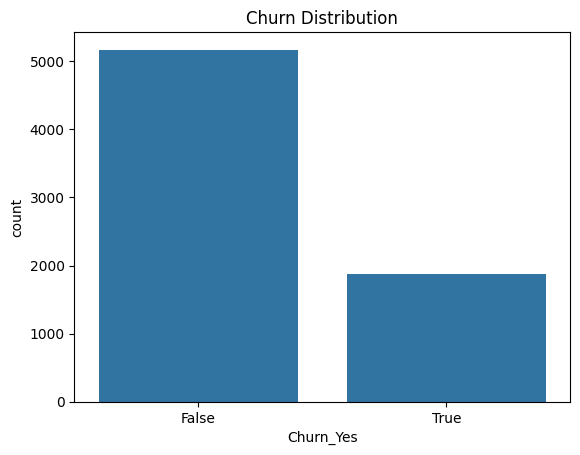

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn_Yes', data=df)
plt.title("Churn Distribution")
plt.show()

# **2. Tenure vs Churn**

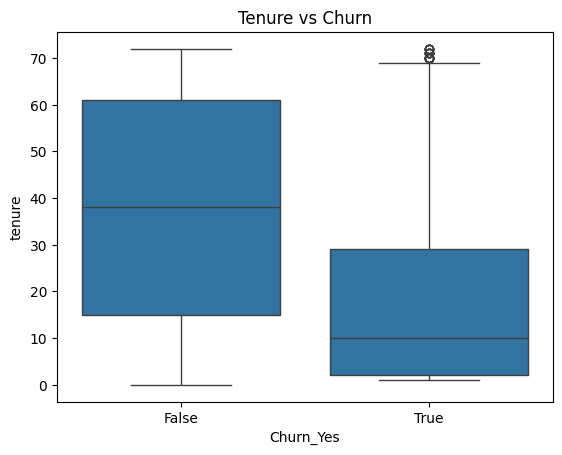

In [ ]:
sns.boxplot(x='Churn_Yes', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

# **3. Monthly Charges vs Churn**

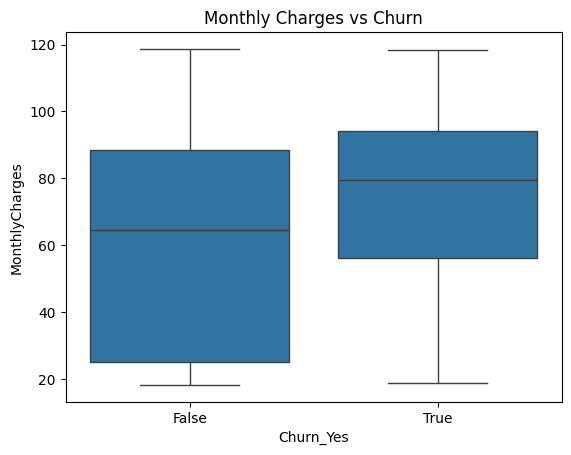

In [ ]:
sns.boxplot(x='Churn_Yes', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

# **4. Correlation Heatmap**

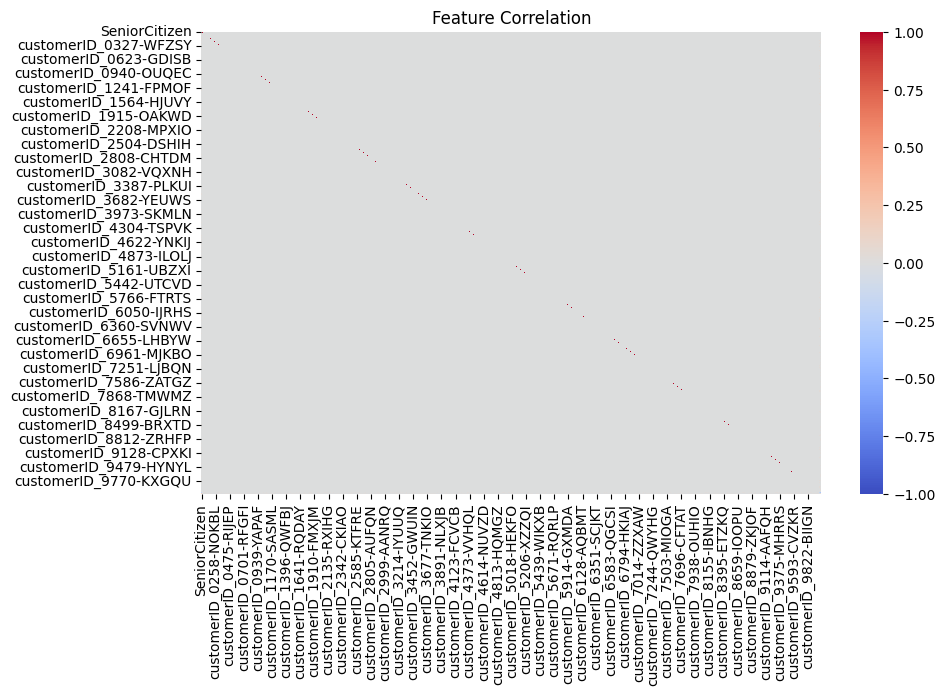

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

# **5. Confusion Matrix**

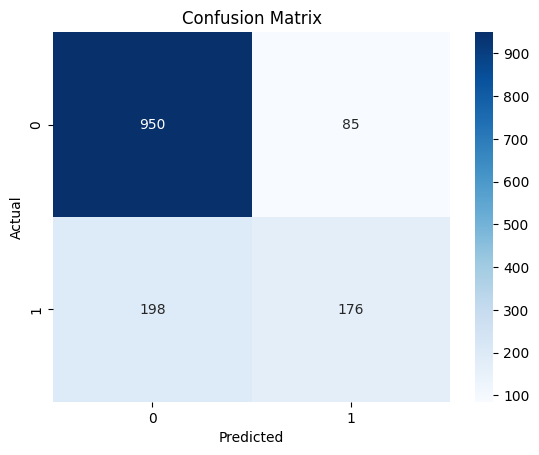

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import os

output_dir = '../outputs/'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))

<Figure size 640x480 with 0 Axes>

# **6. Feature Importance**

In [ ]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')

plt.title("Top 10 Important Features")
plt.show()

NameError: name 'model' is not defined

In [ ]:
plt.savefig('../outputs/feature_importance.png')